# To quantise the possible distances and speed up to the computations of K

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions
%load_ext memory_profiler
# # Global parameters:
number_of_cycles = 500 # how many passes through the training data we go through
number_of_groups = 100 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 5
dims = 2  # 2D spatial
head= 0
puck_list = ['Puck_230517_39'] # the largest puck
# gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    # "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    # "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
gene_list = ["Inha"]
adata, X,Y,df, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)

cuda


ValueError: not enough values to unpack (expected 5, got 4)

## Summary Statistics about torch.cdist(X,X)

In [2]:
X_dist = torch.cdist(X,X)
# Step 1: Create a boolean mask that identifies the off-diagonal elements
off_diagonal_mask = ~torch.eye(X_dist.size(0), dtype=bool)

# Step 2: Use the mask to extract only the off-diagonal elements
off_diagonal_elements = X_dist[off_diagonal_mask]

# Step 3: Flatten the off-diagonal elements
off_diagonal = off_diagonal_elements.flatten()

flat_matrix = torch.flatten(off_diagonal)
df = pd.DataFrame(flat_matrix)
df.describe()

,0
count,2.530167e+08
mean,2.497096e-01
std,1.222957e-01
min,1.753283e-03
25%,1.545553e-01
50%,2.418945e-01
75%,3.370842e-01
max,6.385796e-01


In [3]:
df.max()/df.min()

0    364.219437
dtype: float64

This shows that the furtherest distnace between two points and the closest distance two points are only 365 times apart from each other

## Let us do 800 locations, so that histogram plotting is possible

In [3]:
head = 800 # how many locations to consider in the real data set.
adata, X,Y,df, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
df

,x,y,Inha
CCNCAAGGAAGGGC-1-2,0.17476,-0.02056,0.572946
ACGATCGCTTAGAG-1-2,-0.12338,-0.06588,0.286632
GGATCTGAAGTCGC-1-2,-0.23928,0.11008,0.000000
GATNTTTGACACGC-1-2,0.13450,-0.13804,0.859012
GAAGACGAGGGTAC-1-2,0.04204,-0.04502,0.572946
...,...,...,...
AATTCCGCGGGCAC-1-2,0.08718,0.31144,0.000000
AAGGAGTGGTAGCG-1-2,-0.12150,-0.19706,0.000000
ACTATCCCAGAACA-1-2,0.11148,0.08322,0.000000
CAGCCTCGATACTA-1-2,-0.02298,-0.09240,0.286632


In [4]:
X_dist = torch.cdist(X,X)
# Step 1: Create a boolean mask that identifies the off-diagonal elements
off_diagonal_mask = ~torch.eye(X_dist.size(0), dtype=bool)

# Step 2: Use the mask to extract only the off-diagonal elements
off_diagonal_elements = X_dist[off_diagonal_mask]

# Step 3: Flatten the off-diagonal elements
off_diagonal = off_diagonal_elements.flatten()

flat_matrix = torch.flatten(off_diagonal)
len(flat_matrix)

639200

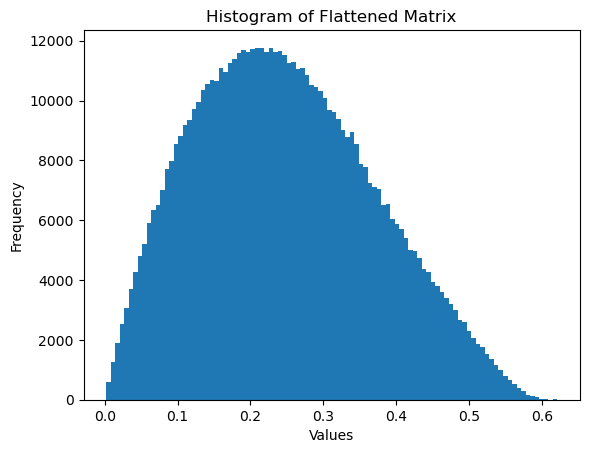

In [5]:
# Plot the histogram directly using the PyTorch tensor
plt.hist(flat_matrix, bins=100)
plt.title('Histogram of Flattened Matrix')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

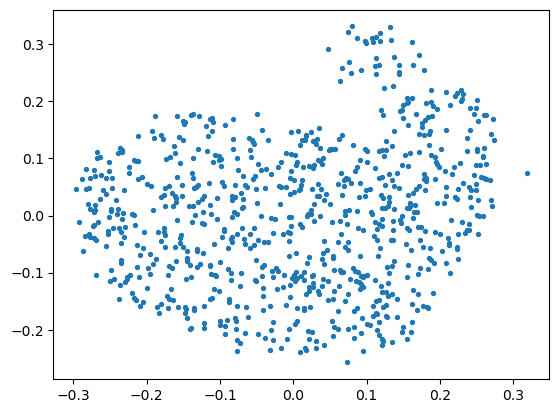

In [6]:
plt.scatter(X[:,0], X[:,1], s=8)

## An approximate method for computing K

In [7]:
alpha_i = torch.tensor(0.01, dtype=torch.float64, device=device).requires_grad_(True)
nu_i = torch.tensor(1.0, dtype=torch.float64, device=device).requires_grad_(True)
sigma_i = torch.tensor(1.0, dtype=torch.float64, device=device).requires_grad_(True)
K_approx =approx_matern_kernel_marginal(X, nu_i, alpha_i, sigma_i, epsilon=1e-9)

In [8]:
K = matern_kernel(torch.cdist(X, X), nu_i, alpha_i, sigma_i)

In [9]:
torch.norm(K, p='fro')**2

tensor(37.2780, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)

In [10]:
torch.norm(K_approx, p='fro')**2

tensor(37.2782, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)

In [11]:
torch.norm(K_approx - K, p='fro')**2

tensor(0.0043, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)

In [12]:
(torch.norm(K_approx - K, p='fro') / torch.norm(K, p='fro'))**2

tensor(1.3413e-08, dtype=torch.float64, grad_fn=<PowBackward0>)

## Do the same for the cross fitting function

In [2]:
# Define test parameters
p = 2  # Number of parameters (for alpha, nu, sigma matrices)
n_locations = 3  # Number of locations
dimensions = 2  # Dimensionality of the locations

# Randomly generate test inputs
X = torch.randn(n_locations, dimensions)
alpha_matrix = torch.rand(p, p)
nu_matrix = torch.rand(p, p)
sigma_matrix = torch.rand(p, p)

# Exact computation using compute_matern_covariance
exact_covariance = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)

# Approximate computation using approx_matern_kernel_cross
approx_covariance = approx_matern_kernel_cross(nu_matrix, alpha_matrix, sigma_matrix, X)

# Compare the Frobenius norm of the difference between the exact and approximate covariance matrices
frobenius_norm_difference = (torch.norm(exact_covariance - approx_covariance, p='fro')**2) / (torch.norm(exact_covariance, p='fro')**2)

print(f"noramlised Frobenius norm of the difference: {frobenius_norm_difference.item()}")

# Set a tolerance level to check if the approximation is sufficiently close
tolerance = 1e-2
assert frobenius_norm_difference < tolerance, "The approximation is not close enough to the exact solution"
print("Test passed: The approximate covariance matrix is sufficiently close to the exact one.")

noramlised Frobenius norm of the difference: 2.9387358727440874e-08
Test passed: The approximate covariance matrix is sufficiently close to the exact one.


In [3]:
torch.norm(exact_covariance - approx_covariance, p='fro')**2

tensor(2.2772e-07, dtype=torch.float64)

In [4]:
torch.norm(exact_covariance, p='fro')**2

tensor(7.7489, dtype=torch.float64)

In [5]:
torch.norm(approx_covariance, p='fro')**2

tensor(7.7495, dtype=torch.float64)

In [6]:
exact_covariance

tensor([[7.9127e-01, 5.0814e-01, 6.8895e-02, 8.1191e-01, 1.7334e-01, 1.0272e-03],
        [5.0814e-01, 7.9127e-01, 6.1630e-02, 1.7334e-01, 8.1191e-01, 7.8314e-04],
        [6.8895e-02, 6.1630e-02, 7.9127e-01, 1.0272e-03, 7.8314e-04, 8.1191e-01],
        [7.2481e-01, 3.2575e-02, 1.1760e-05, 7.5717e-01, 2.5703e-02, 2.7744e-07],
        [3.2575e-02, 7.2481e-01, 7.8133e-06, 2.5703e-02, 7.5717e-01, 1.5154e-07],
        [1.1760e-05, 7.8133e-06, 7.2481e-01, 2.7744e-07, 1.5154e-07, 7.5717e-01]],
       dtype=torch.float64)

In [7]:
approx_covariance

tensor([[7.9127e-01, 5.0836e-01, 6.8955e-02, 8.1191e-01, 1.7357e-01, 1.0294e-03],
        [5.0836e-01, 7.9127e-01, 6.1630e-02, 1.7357e-01, 8.1191e-01, 7.8314e-04],
        [6.8955e-02, 6.1630e-02, 7.9127e-01, 1.0294e-03, 7.8314e-04, 8.1191e-01],
        [7.2481e-01, 3.2643e-02, 1.1798e-05, 7.5717e-01, 2.5776e-02, 2.7875e-07],
        [3.2643e-02, 7.2481e-01, 7.8133e-06, 2.5776e-02, 7.5717e-01, 1.5154e-07],
        [1.1798e-05, 7.8133e-06, 7.2481e-01, 2.7875e-07, 1.5154e-07, 7.5717e-01]],
       dtype=torch.float64)

## Compute the pairwise distance histogram for a regular 15 by 15 or 30 by 30 grid.

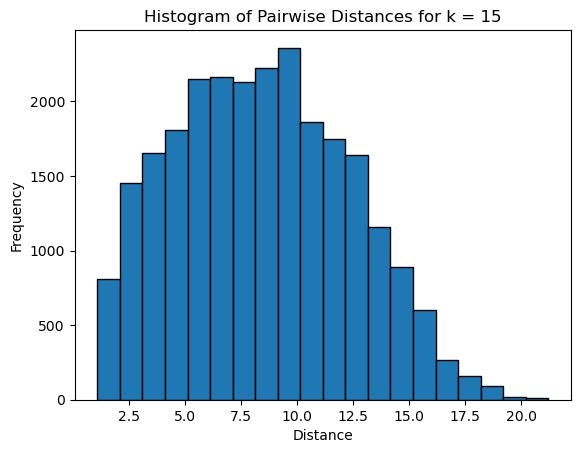

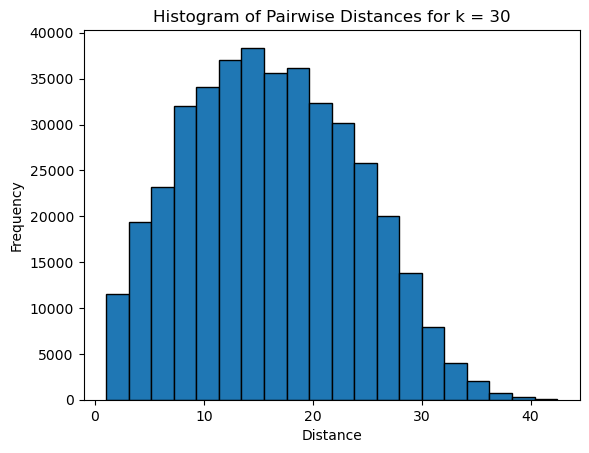

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def create_grid_and_plot_histogram(k):
    # Create a regular k by k grid of points
    x = np.linspace(0, k, k)
    y = np.linspace(0, k, k)
    
    # Create a meshgrid of x and y coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten the grid to get a list of 2D points
    points = np.vstack([xx.ravel(), yy.ravel()]).T
    
    # Compute all pairwise distances using Euclidean distance
    distances = pdist(points, metric='euclidean')
    
    # Plot the histogram of the pairwise distances
    plt.hist(distances, bins=20, edgecolor='black')
    plt.title(f'Histogram of Pairwise Distances for k = {k}')
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.show()

# Plot for k = 15
create_grid_and_plot_histogram(15)

# Plot for k = 30
create_grid_and_plot_histogram(30)